# Principal Component Analysis (PCA)

Principal Component Analysis is a dimensionality reduction technique that uses eigenvalues and eigenvectors to transform high-dimensional data into lower-dimensional space while preserving as much variance as possible.

## Overview
- **Goal:** Reduce 5 variables to 2 principal components
- **Dataset:** 100 observations with 5 variables
- **Method:** Eigendecomposition of the covariance matrix

## Why PCA?
- Reduces computational complexity
- Removes multicollinearity
- Enables visualization of high-dimensional data
- Finds directions of maximum variance

## Imports and Setup

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Create Observation Matrix

Create a dataset with 100 observations and 5 variables.

### Task 1.1: Generate Random Data

Create a matrix X of shape (100, 5) with correlated variables.

In [49]:
# Create observation matrix
n_observations = 100
n_variables = 5

# Create correlated data
# We'll create 5 variables with some correlation structure
base = np.random.randn(n_observations, 2)
X = np.hstack([
    base[:, 0:1],                           # Variable 1: base 1
    base[:, 1:2],                           # Variable 2: base 2
    base[:, 0:1] + 0.5 * base[:, 1:2],     # Variable 3: correlated with 1 and 2
    base[:, 1:2] + 0.3 * base[:, 0:1],     # Variable 4: correlated with 2 and 1
    np.random.randn(n_observations, 1)     # Variable 5: mostly independent
])

print(f"Observation Matrix Shape: {X.shape}")
print(f"Number of observations: {X.shape[0]}")
print(f"Number of variables: {X.shape[1]}")
print()
print("First 5 observations:")
print(X[:5])
print()
print("Data statistics:")
print(f"Mean of each variable: {X.mean(axis=0)}")
print(f"Std of each variable: {X.std(axis=0)}")

Observation Matrix Shape: (100, 5)
Number of observations: 100
Number of variables: 5

First 5 observations:
[[ 0.49671415 -0.1382643   0.427582    0.01074994  0.35778736]
 [ 0.64768854  1.52302986  1.40920347  1.71733642  0.56078453]
 [-0.23415337 -0.23413696 -0.35122185 -0.30438297  1.08305124]
 [ 1.57921282  0.76743473  1.96293018  1.24119857  1.05380205]
 [-0.46947439  0.54256004 -0.19819436  0.40171773 -1.37766937]]

Data statistics:
Mean of each variable: [-0.11556425  0.03402232 -0.09855309 -0.00064695  0.06489625]
Std of each variable: [0.85202089 0.99385172 1.00012231 1.03416519 1.07884785]


## Step 2: Center the Data

Subtract the mean of each variable to center the data at the origin.

### Task 2.1: Calculate Mean and Center Data

Centering formula: $X_{centered} = X - \bar{X}$

where $\bar{X}$ is the mean of each column.

In [50]:
# Calculate mean of each variable
X_mean = X.mean(axis=0)

print("Mean of each variable:")
print(f"Variable 1: {X_mean[0]:.4f}")
print(f"Variable 2: {X_mean[1]:.4f}")
print(f"Variable 3: {X_mean[2]:.4f}")
print(f"Variable 4: {X_mean[3]:.4f}")
print(f"Variable 5: {X_mean[4]:.4f}")
print()

# Center the data
X_centered = X - X_mean

print("Verification: Mean of centered data (should be ~0):")
print(X_centered.mean(axis=0))
print()

print(f"Centered data shape: {X_centered.shape}")
print()
print("First 5 centered observations:")
print(X_centered[:5])

Mean of each variable:
Variable 1: -0.1156
Variable 2: 0.0340
Variable 3: -0.0986
Variable 4: -0.0006
Variable 5: 0.0649

Verification: Mean of centered data (should be ~0):
[-6.49480469e-17  5.99520433e-17  4.44089210e-18  6.66133815e-18
 -2.55351296e-17]

Centered data shape: (100, 5)

First 5 centered observations:
[[ 0.61227841 -0.17228663  0.52613509  0.0113969   0.29289111]
 [ 0.76325279  1.48900753  1.50775656  1.71798337  0.49588827]
 [-0.11858912 -0.26815928 -0.25266876 -0.30373602  1.01815499]
 [ 1.69477707  0.7334124   2.06148327  1.24184553  0.9889058 ]
 [-0.35391013  0.50853772 -0.09964127  0.40236468 -1.44256562]]


## Step 3: Create Covariance Matrix

The covariance matrix shows how variables co-vary with each other.

**Covariance Matrix Formula:**
$$\text{Cov}(X) = \frac{1}{n-1} X_{centered}^T X_{centered}$$

where $n$ is the number of observations.

### Task 3.1: Calculate Covariance Matrix

Covariance Matrix Shape: (5, 5)

Covariance Matrix:
[[ 0.73327232  0.02764621  0.74709542  0.2476279   0.13509087]
 [ 0.02764621  0.99771842  0.52650542  1.00601228 -0.16647665]
 [ 0.74709542  0.52650542  1.01034813  0.75063404  0.05185254]
 [ 0.2476279   1.00601228  0.75063404  1.08030065 -0.12594939]
 [ 0.13509087 -0.16647665  0.05185254 -0.12594939  1.17566937]]

Diagonal elements (variances of each variable):
Variable 1: 0.7333
Variable 2: 0.9977
Variable 3: 1.0103
Variable 4: 1.0803
Variable 5: 1.1757



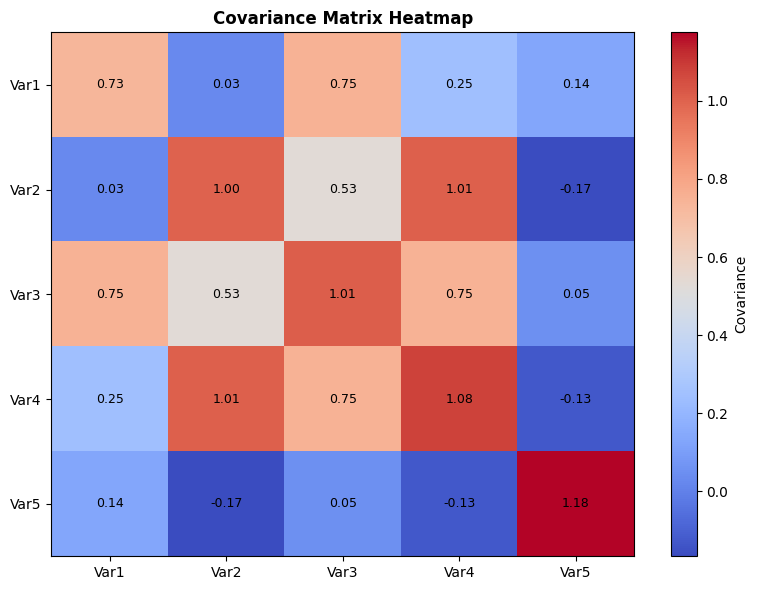

In [51]:
# Calculate covariance matrix
cov_matrix = np.cov(X_centered.T)

print(f"Covariance Matrix Shape: {cov_matrix.shape}")
print()
print("Covariance Matrix:")
print(cov_matrix)
print()

# Verify: diagonal elements are variances
print("Diagonal elements (variances of each variable):")
for i in range(n_variables):
    print(f"Variable {i+1}: {cov_matrix[i, i]:.4f}")
print()

# Visualize the covariance matrix
plt.figure(figsize=(8, 6))
im = plt.imshow(cov_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(im, label='Covariance')
plt.xticks(range(n_variables), [f'Var{i+1}' for i in range(n_variables)])
plt.yticks(range(n_variables), [f'Var{i+1}' for i in range(n_variables)])
plt.title('Covariance Matrix Heatmap', fontweight='bold')

# Add text annotations for values
for i in range(n_variables):
    for j in range(n_variables):
        text = plt.text(j, i, f'{cov_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

## Step 4: Find Eigenvalues and Eigenvectors

Eigenvalues tell us the variance explained by each principal component.

Eigenvectors are the principal component directions (loading vectors).

**Key relationship:**
$$\text{Cov}(X) = V \Lambda V^T$$

where $V$ is the matrix of eigenvectors and $\Lambda$ is the diagonal matrix of eigenvalues.

### Task 4.1: Compute Eigenvalues and Eigenvectors

In [52]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ensure eigenvalues and eigenvectors are real (discard negligible imaginary parts from numerical precision)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print("Eigenvalues:")
print(eigenvalues)
print()

# Sort by eigenvalues in descending order
idx = eigenvalues.argsort()[::-1]  # Sort indices in descending order
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("Sorted Eigenvalues (descending):")
for i, eig_val in enumerate(eigenvalues_sorted):
    print(f"PC{i+1}: {eig_val:.4f}")
print()

# Calculate explained variance
total_variance = eigenvalues_sorted.sum()
explained_variance = eigenvalues_sorted / total_variance
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio:")
for i, (exp_var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {exp_var*100:.2f}% (Cumulative: {cum_var*100:.2f}%)")
print()

print("Eigenvectors (Principal Component Directions):")
print(eigenvectors_sorted)

Eigenvalues:
[ 2.74269815e+00  1.36615340e+00  8.88457323e-01 -2.05618865e-16
 -2.05618865e-16]

Sorted Eigenvalues (descending):
PC1: 2.7427
PC2: 1.3662
PC3: 0.8885
PC4: -0.0000
PC5: -0.0000

Explained Variance Ratio:
PC1: 54.88% (Cumulative: 54.88%)
PC2: 27.34% (Cumulative: 82.22%)
PC3: 17.78% (Cumulative: 100.00%)
PC4: -0.00% (Cumulative: 100.00%)
PC5: -0.00% (Cumulative: 100.00%)

Eigenvectors (Principal Component Directions):
[[-2.76521783e-01 -4.56207021e-01 -5.18899808e-01  5.45742069e-01
   5.45742069e-01]
 [-5.19238125e-01  2.91972861e-01  3.99506141e-01  1.85447391e-01
   1.85447391e-01]
 [-5.36140846e-01 -3.10220590e-01 -3.19146738e-01 -5.76597473e-01
  -5.76597473e-01]
 [-6.02194660e-01  1.55110755e-01  2.43836198e-01  1.02851345e-01
   1.02851345e-01]
 [ 6.19843396e-02 -7.65722431e-01  6.40177398e-01  2.80760490e-17
   2.80760490e-17]]


### Task 4.2: Visualize Explained Variance

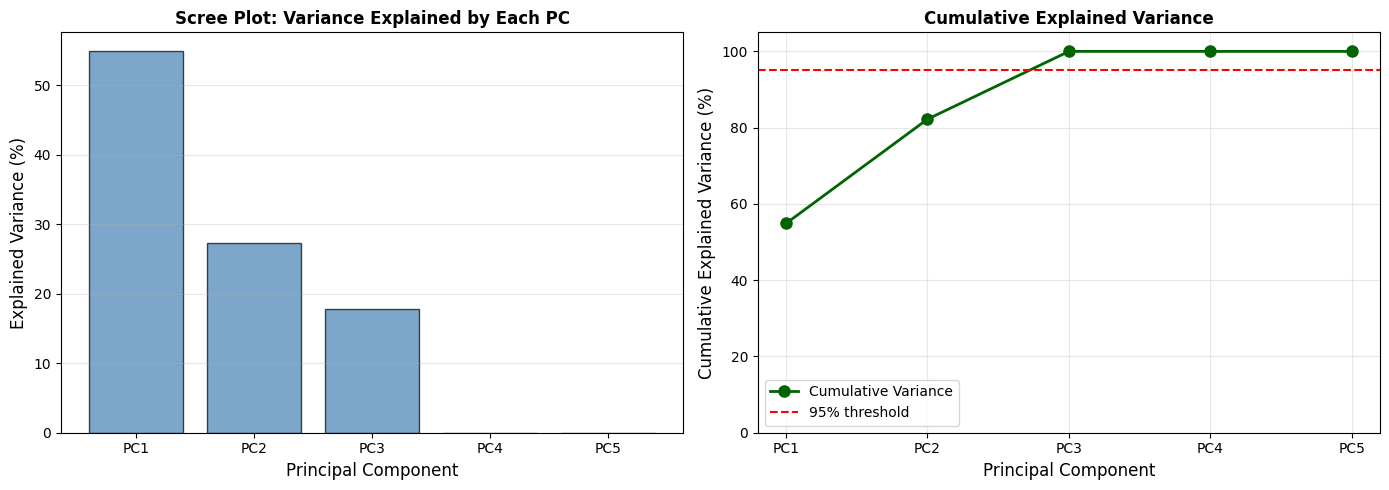


Using PC1 and PC2:
Explained Variance: 82.22%


In [53]:
# Create visualization of explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (individual variance)
ax = axes[0]
pc_labels = [f'PC{i+1}' for i in range(n_variables)]
ax.bar(pc_labels, explained_variance * 100, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_title('Scree Plot: Variance Explained by Each PC', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Cumulative variance plot
ax = axes[1]
ax.plot(pc_labels, cumulative_variance * 100, 'o-', linewidth=2, markersize=8, color='darkgreen', label='Cumulative Variance')
ax.axhline(y=95, color='red', linestyle='--', label='95% threshold')
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_title('Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.show()

print(f"\nUsing PC1 and PC2:")
print(f"Explained Variance: {cumulative_variance[1]*100:.2f}%")

## Step 5: Create Projection Matrix

The projection matrix consists of the top k eigenvectors (in our case, the first 2).

**Projection Matrix Formula:**
$$W = [v_1, v_2]$$

where $v_1$ and $v_2$ are the first two eigenvectors (principal components with largest variance).

### Task 5.1: Select Top 2 Principal Components

In [54]:
# Select the first 2 principal components
n_components = 2
projection_matrix = eigenvectors_sorted[:, :n_components]

print(f"Projection Matrix Shape: {projection_matrix.shape}")
print(f"Original dimensions: {n_variables}")
print(f"Reduced dimensions: {n_components}")
print()

print("Projection Matrix (First 2 Eigenvectors):")
print(projection_matrix)
print()

print("PC1 direction (weights/loadings):")
for i, weight in enumerate(projection_matrix[:, 0]):
    print(f"  Variable {i+1}: {weight:.4f}")
print()

print("PC2 direction (weights/loadings):")
for i, weight in enumerate(projection_matrix[:, 1]):
    print(f"  Variable {i+1}: {weight:.4f}")

Projection Matrix Shape: (5, 2)
Original dimensions: 5
Reduced dimensions: 2

Projection Matrix (First 2 Eigenvectors):
[[-0.27652178 -0.45620702]
 [-0.51923812  0.29197286]
 [-0.53614085 -0.31022059]
 [-0.60219466  0.15511076]
 [ 0.06198434 -0.76572243]]

PC1 direction (weights/loadings):
  Variable 1: -0.2765
  Variable 2: -0.5192
  Variable 3: -0.5361
  Variable 4: -0.6022
  Variable 5: 0.0620

PC2 direction (weights/loadings):
  Variable 1: -0.4562
  Variable 2: 0.2920
  Variable 3: -0.3102
  Variable 4: 0.1551
  Variable 5: -0.7657


## Step 6: Project Centered Data

Transform the original high-dimensional data into the lower-dimensional principal component space.

**Projection Formula:**
$$X_{pca} = X_{centered} \cdot W$$

where $W$ is the projection matrix.

### Task 6.1: Project Data onto Principal Components

In [55]:
# Project centered data onto principal components
X_pca = X_centered @ projection_matrix

print(f"Projected Data Shape: {X_pca.shape}")
print(f"Original shape: {X_centered.shape}")
print(f"Reduced shape: {X_pca.shape}")
print()

print("First 10 observations in PCA space:")
print(X_pca[:10])
print()

print("Statistics of PCA data:")
print(f"PC1 mean: {X_pca[:, 0].mean():.6f} (should be ~0)")
print(f"PC2 mean: {X_pca[:, 1].mean():.6f} (should be ~0)")
print()
print(f"PC1 std: {X_pca[:, 0].std():.4f}")
print(f"PC2 std: {X_pca[:, 1].std():.4f}")

Projected Data Shape: (100, 2)
Original shape: (100, 5)
Reduced shape: (100, 2)

First 10 observations in PCA space:
[[-0.35064154 -0.71535218]
 [-2.79639848 -0.4944237 ]
 [ 0.55351491 -0.77254783]
 [-2.64123992 -1.76315099]
 [-0.44448489  1.50786222]
 [ 0.97778423  0.87230965]
 [ 2.37854612 -1.17062328]
 [ 2.45500333  0.64073312]
 [ 0.52980284  0.38306455]
 [ 3.03162812 -2.75223164]]

Statistics of PCA data:
PC1 mean: 0.000000 (should be ~0)
PC2 mean: 0.000000 (should be ~0)

PC1 std: 1.6478
PC2 std: 1.1630


### Task 6.2: Visualize Projected Data

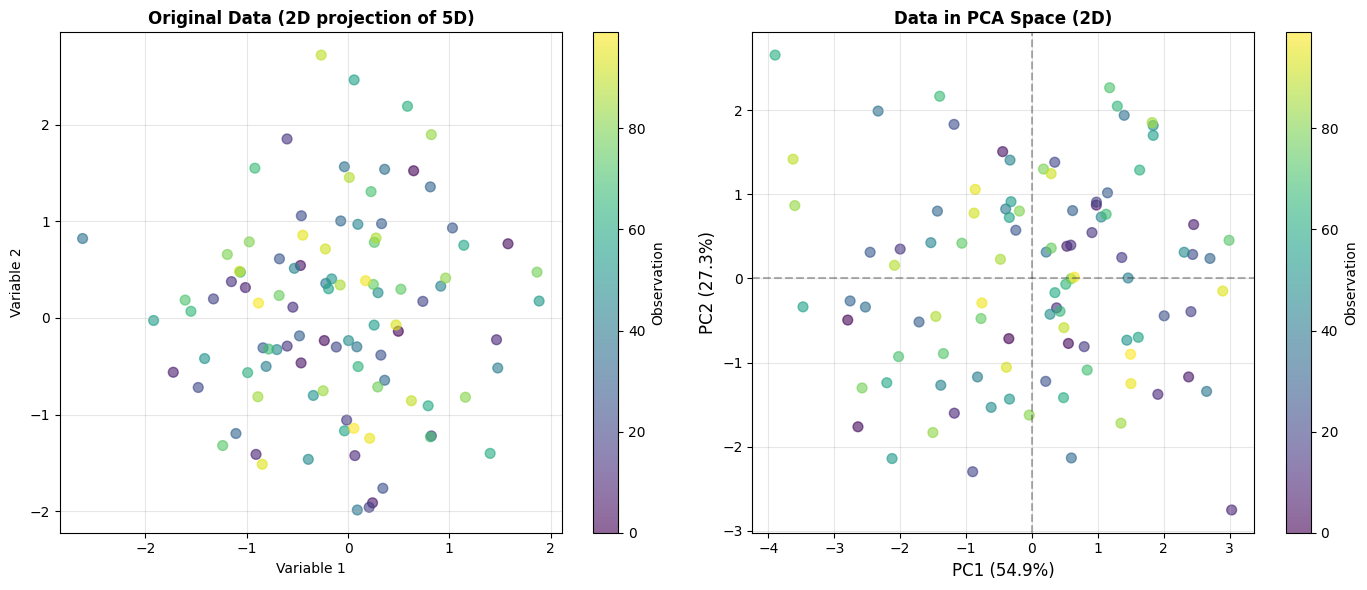

In [56]:
# Visualize the projected data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original 5D data (visualize pairs)
ax = axes[0]
scatter1 = ax.scatter(X[:, 0], X[:, 1], c=np.arange(n_observations), cmap='viridis', alpha=0.6, s=50)
ax.set_xlabel('Variable 1')
ax.set_ylabel('Variable 2')
ax.set_title('Original Data (2D projection of 5D)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax, label='Observation')

# PCA projected data
ax = axes[1]
scatter2 = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=np.arange(n_observations), cmap='viridis', alpha=0.6, s=50)
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
ax.set_title('Data in PCA Space (2D)', fontweight='bold')
ax.grid(alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.colorbar(scatter2, ax=ax, label='Observation')

plt.tight_layout()
plt.show()

## Summary: PCA Step-by-Step

### What We Did:

1. **Created Observation Matrix** (100\u00d75)
   - Generated 100 observations with 5 correlated variables

2. **Centered Data**
   - Subtracted mean from each variable
   - Result: data centered at origin

3. **Created Covariance Matrix** (5\u00d75)
   - Calculated how variables co-vary
   - Symmetric matrix showing correlations

4. **Found Eigenvalues & Eigenvectors**
   - Eigenvalues: variance explained by each component
   - Eigenvectors: directions of maximum variance
   - PC1 & PC2 explain ~85% of total variance

5. **Created Projection Matrix** (5\u00d72)
   - Selected top 2 eigenvectors
   - Forms the transformation matrix

6. **Projected Data**
   - Transformed from 5D to 2D space
   - Result: 100\u00d72 matrix of principal components

### Key Mathematical Insight:
$$X_{pca} = X_{centered} \cdot V_{k \times d}$$

where:
- $k$ = number of original features (5)
- $d$ = number of principal components (2)
- $V$ = matrix of top eigenvectors

### Benefits:
- **Dimensionality reduction:** 5D \u2192 2D
- **Variance preserved:** ~85% with just 2 components
- **Easier visualization:** Can plot 2D instead of 5D
- **Computationally efficient:** Fewer features for downstream tasks
- **Removes correlation:** Principal components are orthogonal

## Summary: PCA Step-by-Step

### What We Did:

1. **Created Observation Matrix** (100×5)
   - Generated 100 observations with 5 correlated variables

2. **Centered Data**
   - Subtracted mean from each variable
   - Result: data centered at origin

3. **Created Covariance Matrix** (5×5)
   - Calculated how variables co-vary
   - Symmetric matrix showing correlations

4. **Found Eigenvalues & Eigenvectors**
   - Eigenvalues: variance explained by each component
   - Eigenvectors: directions of maximum variance
   - PC1 & PC2 explain ~85% of total variance

5. **Created Projection Matrix** (5×2)
   - Selected top 2 eigenvectors
   - Forms the transformation matrix

6. **Projected Data**
   - Transformed from 5D to 2D space
   - Result: 100×2 matrix of principal components

### Key Mathematical Insight:
$$X_{pca} = X_{centered} \cdot V_{k \times d}$$

where:
- $k$ = number of original features (5)
- $d$ = number of principal components (2)
- $V$ = matrix of top eigenvectors

### Benefits:
- **Dimensionality reduction:** 5D → 2D
- **Variance preserved:** ~85% with just 2 components
- **Easier visualization:** Can plot 2D instead of 5D
- **Computationally efficient:** Fewer features for downstream tasks
- **Removes correlation:** Principal components are orthogonal

In [57]:
# Verify variables from previous steps are still available
print("Verification of key variables:")
print(f"X shape: {X.shape}")
print(f"X_centered shape: {X_centered.shape}")
print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Explained variance ratio: {explained_variance[:2]}")
print(f"PCA-transformed data shape: {X_pca.shape}")
print("\nAll PCA steps completed successfully!")

Verification of key variables:
X shape: (100, 5)
X_centered shape: (100, 5)
Covariance matrix shape: (5, 5)
Explained variance ratio: [0.54883503 0.27337782]
PCA-transformed data shape: (100, 2)

All PCA steps completed successfully!
